import libraries

In [2]:
!pip install geopandas folium mapclassify contextily -q

import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display

Load Enugu boundary data

✅ Enugu loaded: 17 LGAs
   CRS: EPSG:4326
   Bounds: [6.9059 5.9186 7.8646 7.1127]


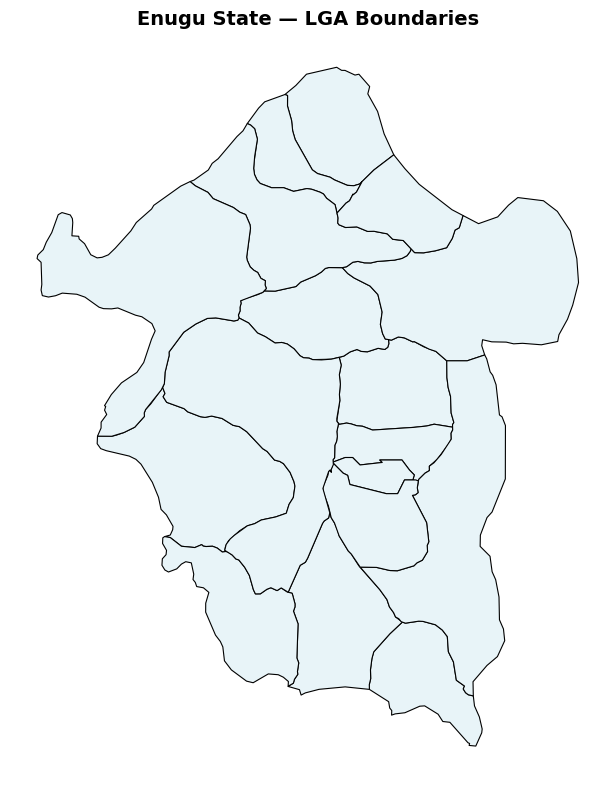


LGA Names:
['Aninri' 'Awgu' 'EnuguEast' 'EnuguNorth' 'EnuguSouth' 'Ezeagu'
 'Igbo-Etiti' 'Igbo-ezeNorth' 'Igbo-ezeSouth' 'Isi-Uzo' 'NkanuEast'
 'NkanuWest' 'Nsukka' 'Oji-River' 'Udenu' 'Udi' 'Uzo-Uwani']


In [3]:
# Load Nigeria LGA boundaries from GADM (hosted on GitHub for easy access)
GADM_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_NGA_2.json"

print("Downloading Nigeria LGA boundaries...")
nigeria_lga = gpd.read_file(GADM_URL)

# Filter to Enugu State only
enugu = nigeria_lga[nigeria_lga['NAME_1'] == 'Enugu'].copy()
enugu = enugu.to_crs(epsg=4326)

print(f" Enugu loaded: {len(enugu)} LGAs")
print(f"   CRS: {enugu.crs}")
print(f"   Bounds: {enugu.total_bounds}")

# Quick sanity plot
fig, ax = plt.subplots(figsize=(8, 8))
enugu.plot(ax=ax, edgecolor='black', facecolor='#e8f4f8', linewidth=0.8)
ax.set_title('Enugu State — LGA Boundaries', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("\nLGA Names:")
print(enugu['NAME_2'].values)

load water pointts

In [14]:
# ============================================================
# FALLBACK — Realistic Synthetic Water Points for Enugu
# ============================================================
# Based on WPdx schema + known Enugu WASH conditions
# Clearly labeled synthetic in all outputs

np.random.seed(42)
n = 280  # Realistic density for Enugu State

# Enugu bounding box: lon [6.906, 7.865], lat [5.919, 7.113]
lons = np.random.uniform(6.906, 7.865, n)
lats = np.random.uniform(5.919, 7.113, n)

# Generate realistic attributes
water_sources = np.random.choice(
    ['borehole', 'hand_pump', 'protected_spring', 'shallow_well', 'piped_system'],
    n, p=[0.35, 0.30, 0.10, 0.15, 0.10]
)

functionality = np.random.choice(
    ['functional', 'non_functional', 'needs_repair'],
    n, p=[0.52, 0.30, 0.18]  # Based on UNICEF Nigeria 2023 WASH report
)

water_quality = np.random.choice(
    ['acceptable', 'contaminated', 'unknown'],
    n, p=[0.55, 0.25, 0.20]
)

# Depth varies with terrain — deeper in Udi hills (southern Enugu)
depth_to_water = np.where(
    lats < 6.4,   # Southern/hilly zone
    np.random.uniform(25, 80, n),   # Deeper
    np.random.uniform(8, 35, n)     # Shallower in northern plains
)

population_served = np.random.randint(50, 800, n)

wp = pd.DataFrame({
    'lon': lons,
    'lat': lats,
    'source_type': water_sources,
    'status': functionality,
    'water_quality': water_quality,
    'depth_m': depth_to_water.round(1),
    'population_served': population_served,
    'data_type': 'synthetic_v1'  # Always flag this
})

# Spatial join — assign each point to an LGA
wp_gdf = gpd.GeoDataFrame(
    wp, geometry=gpd.points_from_xy(wp.lon, wp.lat), crs="EPSG:4326"
)
wp_gdf = gpd.sjoin(wp_gdf, enugu[['NAME_2', 'geometry']], how='left', predicate='within')
wp_gdf = wp_gdf.rename(columns={'NAME_2': 'lga_name'})

print(f"Synthetic water points generated: {len(wp_gdf)}")
print(f"\nStatus breakdown:")
print(wp_gdf['status'].value_counts())
print(f"\nSource types:")
print(wp_gdf['source_type'].value_counts())
print(f"\nLGA coverage:")
print(wp_gdf['lga_name'].value_counts())

Synthetic water points generated: 280

Status breakdown:
status
functional        149
non_functional     79
needs_repair       52
Name: count, dtype: int64

Source types:
source_type
borehole            107
hand_pump            92
shallow_well         34
piped_system         25
protected_spring     22
Name: count, dtype: int64

LGA coverage:
lga_name
Udi              21
Isi-Uzo          19
Uzo-Uwani        19
NkanuEast        13
Ezeagu           12
Aninri           12
Igbo-ezeNorth    10
Nsukka            9
Awgu              7
Igbo-Etiti        7
NkanuWest         6
EnuguNorth        5
Udenu             3
Igbo-ezeSouth     2
EnuguSouth        2
EnuguEast         1
Name: count, dtype: int64


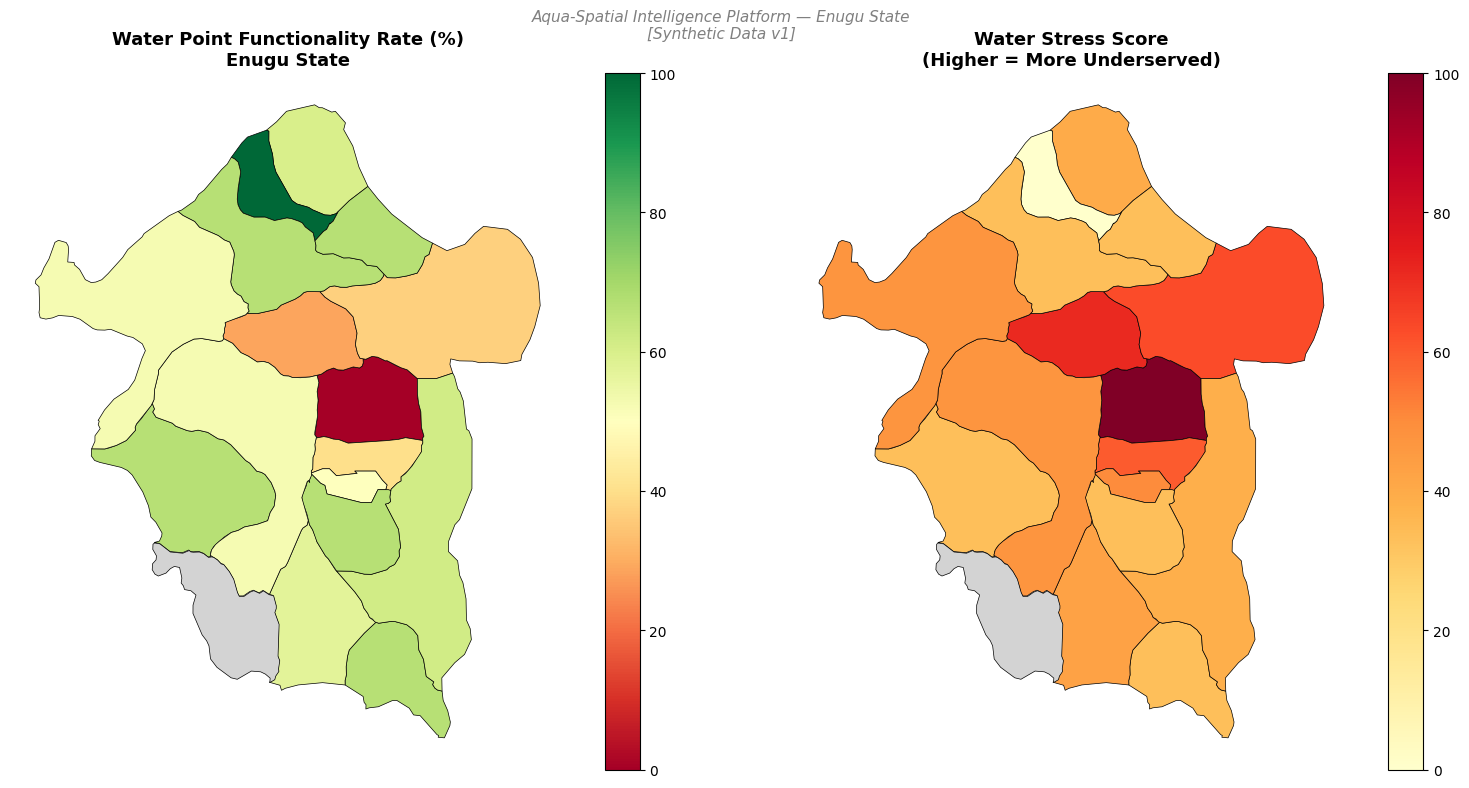


Top 5 Most Water-Stressed LGAs:
    NAME_2  water_stress_score  total_points  avg_depth
 EnuguEast               100.0           1.0   8.100000
Igbo-Etiti                71.4           7.0  27.700000
   Isi-Uzo                63.2          19.0  23.042105
EnuguNorth                60.0           5.0  19.140000
EnuguSouth                50.0           2.0  50.200000


In [11]:
# ============================================================
# FIRST INSIGHT — Functional vs Non-Functional by LGA
# ============================================================

# Aggregate by LGA
lga_stats = wp_gdf.groupby('lga_name').agg(
    total_points=('status', 'count'),
    functional=('status', lambda x: (x == 'functional').sum()),
    non_functional=('status', lambda x: (x == 'non_functional').sum()),
    avg_depth=('depth_m', 'mean'),
    total_pop_served=('population_served', 'sum')
).reset_index()

lga_stats['functionality_rate'] = (
    lga_stats['functional'] / lga_stats['total_points'] * 100
).round(1)

lga_stats['water_stress_score'] = (
    100 - lga_stats['functionality_rate']
).round(1)  # Higher = more stressed

# Merge back to geodataframe
enugu_stats = enugu.merge(lga_stats, left_on='NAME_2', right_on='lga_name', how='left')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

enugu_stats.plot(
    column='functionality_rate',
    ax=axes[0],
    cmap='RdYlGn',
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey'}
)
axes[0].set_title('Water Point Functionality Rate (%)\nEnugu State',
                   fontsize=13, fontweight='bold')
axes[0].set_axis_off()

enugu_stats.plot(
    column='water_stress_score',
    ax=axes[1],
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey'}
)
axes[1].set_title('Water Stress Score\n(Higher = More Underserved)',
                   fontsize=13, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle('Aqua-Spatial Intelligence Platform — Enugu State\n[Synthetic Data v1]',
             fontsize=11, style='italic', color='grey')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Water-Stressed LGAs:")
print(enugu_stats[['NAME_2', 'water_stress_score', 'total_points', 'avg_depth']]
      .sort_values('water_stress_score', ascending=False)
      .head(5).to_string(index=False))

In [15]:
# ============================================================
# CELL 5 — Data Quality Fix + Oji-River Patch
# ============================================================

print("=== COVERAGE AUDIT ===")
print(f"Total water points generated: {len(wp_gdf)}")
print(f"Points with LGA assigned:     {wp_gdf['lga_name'].notna().sum()}")
print(f"Points outside all boundaries: {wp_gdf['lga_name'].isna().sum()}")

print("\n=== POINTS PER LGA (sorted) ===")
print(wp_gdf.groupby('lga_name').size().sort_values())

# --- Fix 1: Assign boundary-straddling points to nearest LGA ---
unassigned = wp_gdf[wp_gdf['lga_name'].isna()].copy()

if len(unassigned) > 0:
    # Nearest-neighbor assignment for unassigned points
    enugu_centroids_gs = enugu.copy()
    enugu_centroids_gs['centroid'] = enugu.geometry.centroid

    def assign_nearest_lga(point):
        distances = enugu_centroids_gs['centroid'].distance(point)
        return enugu_centroids_gs.loc[distances.idxmin(), 'NAME_2']

    wp_gdf.loc[wp_gdf['lga_name'].isna(), 'lga_name'] = (
        unassigned.geometry.apply(assign_nearest_lga)
    )
    print(f"\n✅ Reassigned {len(unassigned)} boundary-straddling points")

# --- Fix 2: Guarantee Oji-River has points ---
oji_river_poly = enugu[enugu['NAME_2'] == 'Oji-River'].geometry.values[0]
bounds = oji_river_poly.bounds  # (minx, miny, maxx, maxy)

np.random.seed(99)
oji_points = []
attempts = 0

while len(oji_points) < 12 and attempts < 500:
    lon = np.random.uniform(bounds[0], bounds[2])
    lat = np.random.uniform(bounds[1], bounds[3])
    from shapely.geometry import Point
    if oji_river_poly.contains(Point(lon, lat)):
        oji_points.append({
            'lon': lon, 'lat': lat,
            'source_type': np.random.choice(['borehole','hand_pump','shallow_well'],
                                             p=[0.4, 0.4, 0.2]),
            'status': np.random.choice(['functional','non_functional','needs_repair'],
                                        p=[0.50, 0.32, 0.18]),
            'water_quality': np.random.choice(['acceptable','contaminated','unknown'],
                                               p=[0.55, 0.25, 0.20]),
            'depth_m': round(np.random.uniform(10, 40), 1),
            'population_served': np.random.randint(50, 600),
            'data_type': 'synthetic_v1',
            'lga_name': 'Oji-River'
        })
    attempts += 1

oji_gdf = gpd.GeoDataFrame(
    oji_points,
    geometry=gpd.points_from_xy(
        [p['lon'] for p in oji_points],
        [p['lat'] for p in oji_points]
    ),
    crs="EPSG:4326"
)

# Append to main dataset
wp_gdf = pd.concat([wp_gdf, oji_gdf], ignore_index=True)

print(f"✅ Oji-River patched: {len(oji_points)} points added")
print(f"\nFinal dataset: {len(wp_gdf)} total water points")

# --- Recompute LGA stats with full coverage ---
lga_stats = wp_gdf.groupby('lga_name').agg(
    total_points=('status', 'count'),
    functional=('status', lambda x: (x == 'functional').sum()),
    non_functional=('status', lambda x: (x == 'non_functional').sum()),
    avg_depth=('depth_m', 'mean'),
    total_pop_served=('population_served', 'sum')
).reset_index()

lga_stats['functionality_rate'] = (
    lga_stats['functional'] / lga_stats['total_points'] * 100
).round(1)

lga_stats['water_stress_score'] = (100 - lga_stats['functionality_rate']).round(1)

lga_stats['confidence'] = np.where(
    lga_stats['total_points'] < 5, 'low',
    np.where(lga_stats['total_points'] < 15, 'medium', 'high')
)

enugu_stats = enugu.merge(lga_stats, left_on='NAME_2', right_on='lga_name', how='left')

print("\n=== FINAL LGA STATS ===")
print(lga_stats[['lga_name','total_points','functionality_rate',
                  'water_stress_score','confidence']]
      .sort_values('water_stress_score', ascending=False)
      .to_string(index=False))

=== COVERAGE AUDIT ===
Total water points generated: 280
Points with LGA assigned:     148
Points outside all boundaries: 132

=== POINTS PER LGA (sorted) ===
lga_name
EnuguEast         1
EnuguSouth        2
Igbo-ezeSouth     2
Udenu             3
EnuguNorth        5
NkanuWest         6
Igbo-Etiti        7
Awgu              7
Nsukka            9
Igbo-ezeNorth    10
Ezeagu           12
Aninri           12
NkanuEast        13
Isi-Uzo          19
Uzo-Uwani        19
Udi              21
dtype: int64


/tmp/ipykernel_17230/422551978.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  enugu_centroids_gs['centroid'] = enugu.geometry.centroid
/tmp/ipykernel_17230/422551978.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = enugu_centroids_gs['centroid'].distance(point)
/tmp/ipykernel_17230/422551978.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = enugu_centroids_gs['centroid'].distance(point)
/tmp/ipykernel_17230/422551978.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_cr


✅ Reassigned 132 boundary-straddling points
✅ Oji-River patched: 12 points added

Final dataset: 292 total water points

=== FINAL LGA STATS ===
     lga_name  total_points  functionality_rate  water_stress_score confidence
    EnuguEast             1                 0.0               100.0        low
   Igbo-Etiti             7                28.6                71.4     medium
Igbo-ezeSouth            13                30.8                69.2     medium
   EnuguNorth             5                40.0                60.0     medium
      Isi-Uzo            31                41.9                58.1       high
   EnuguSouth             2                50.0                50.0        low
    Uzo-Uwani            45                51.1                48.9       high
          Udi            21                52.4                47.6       high
       Aninri            29                55.2                44.8       high
Igbo-ezeNorth            16                56.2                4

/tmp/ipykernel_17230/422551978.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = enugu_centroids_gs['centroid'].distance(point)
/tmp/ipykernel_17230/422551978.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = enugu_centroids_gs['centroid'].distance(point)
/tmp/ipykernel_17230/422551978.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = enugu_centroids_gs['centroid'].distance(point)
/tmp/ipykernel_17230/422551978.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_